# Training — Learning Curves
Training runs on the GPU server via `src/train.py`. This notebook loads the saved history and visualizes the results.

In [5]:
import json
import matplotlib.pyplot as plt

histories = {}
for name in ["alexnet_history", "baseline_history", "shallow_sgd_history", "wide_rmsprop_history"]:
    with open(f"../models/{name}.json") as f:
        histories[name] = json.load(f)

labels = {
    "alexnet_history":      "AlexNet",
    "baseline_history":     "Baseline",
    "shallow_sgd_history":  "Shallow SGD",
    "wide_rmsprop_history": "Wide RMSprop",
}

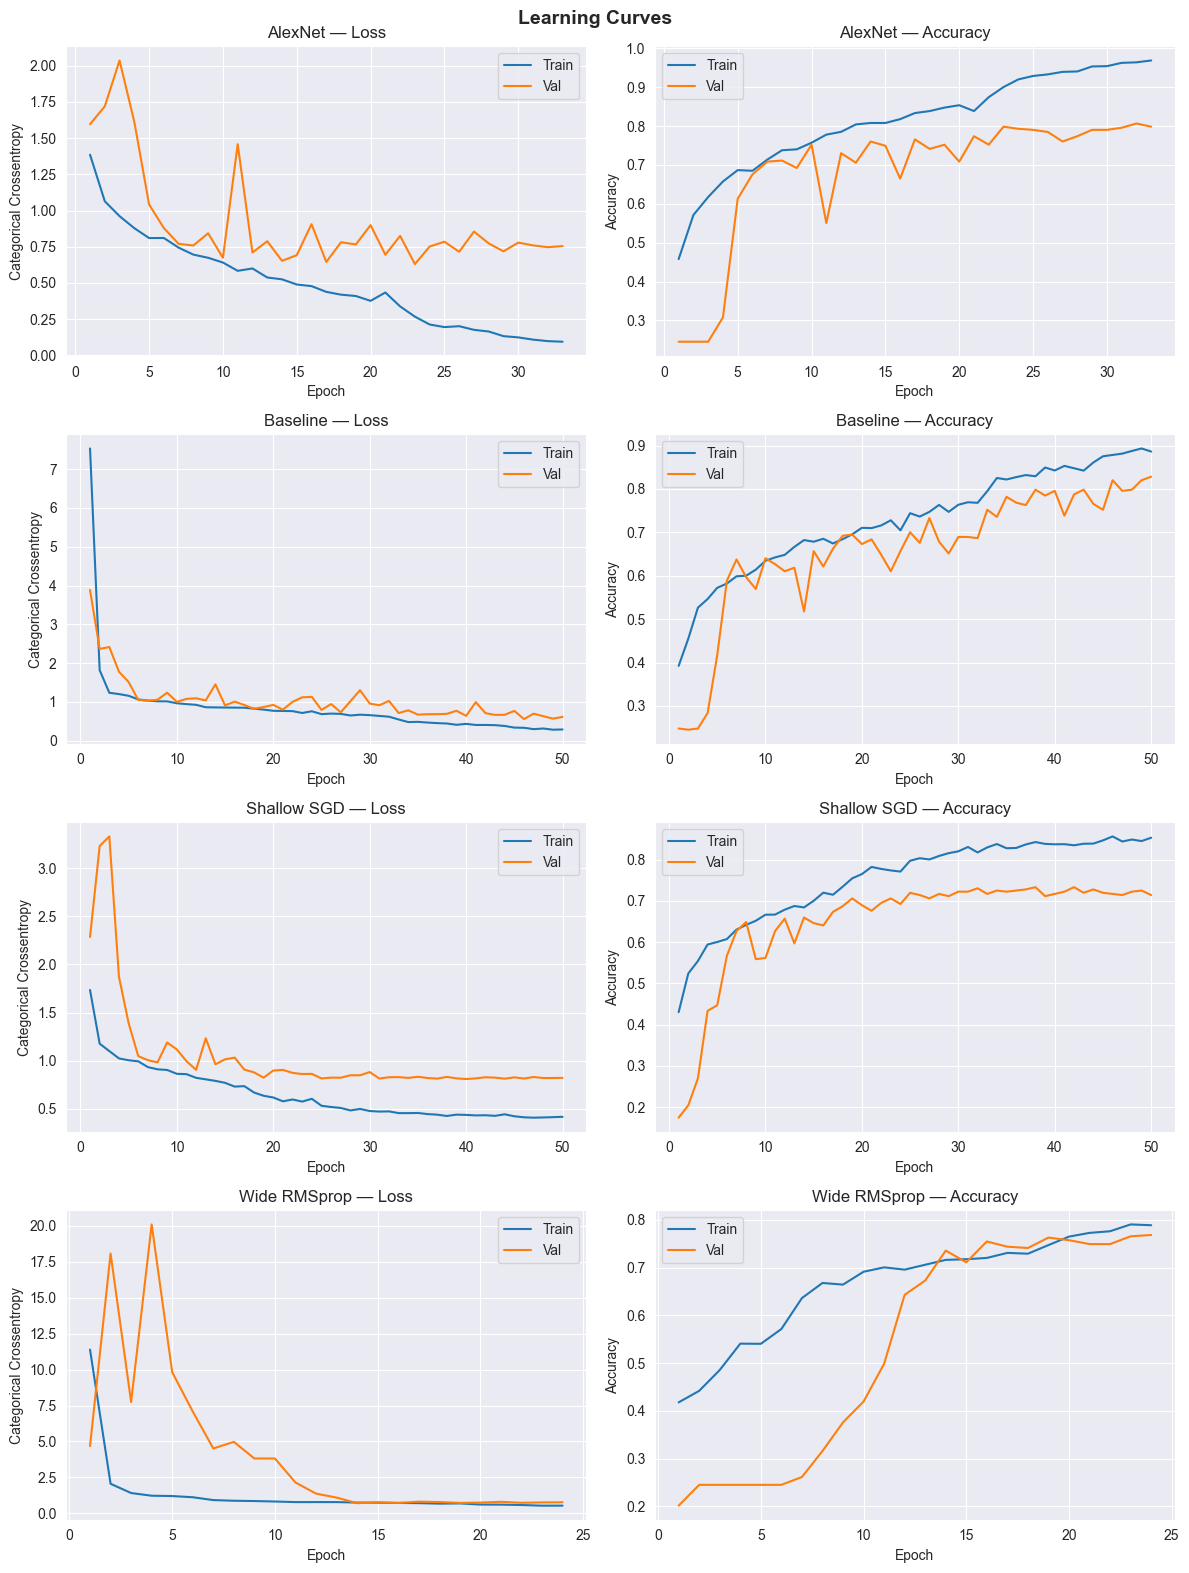

Model                Epochs  Best val acc  Best val loss
--------------------------------------------------------
AlexNet                  33        0.8065         0.6300
Baseline                 50        0.8283         0.5576
Shallow SGD              50        0.7330         0.8087
Wide RMSprop             24        0.7684         0.7143


In [6]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
fig.suptitle("Learning Curves", fontsize=14, fontweight="bold")

for row, (key, label) in enumerate(labels.items()):
    h = histories[key]
    epochs = range(1, len(h["loss"]) + 1)
    ax_loss, ax_acc = axes[row]

    ax_loss.plot(epochs, h["loss"],         label="Train")
    ax_loss.plot(epochs, h["val_loss"],     label="Val")
    ax_loss.set_title(f"{label} — Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Categorical Crossentropy")
    ax_loss.legend()

    ax_acc.plot(epochs, h["accuracy"],      label="Train")
    ax_acc.plot(epochs, h["val_accuracy"],  label="Val")
    ax_acc.set_title(f"{label} — Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()

plt.tight_layout()
plt.show()

print(f"{'Model':<20} {'Epochs':>6}  {'Best val acc':>12}  {'Best val loss':>13}")
print("-" * 56)
for key, label in labels.items():
    h = histories[key]
    print(f"{label:<20} {len(h['loss']):>6}  {max(h['val_accuracy']):>12.4f}  {min(h['val_loss']):>13.4f}")